In [65]:
# Librerie base
import pandas as pd
import numpy as np

# Visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Modelli e metriche
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Salvataggio modello
import joblib
import os

# Per ignorare warning inutili
import warnings
warnings.filterwarnings("ignore")

# Impostazioni grafiche
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [3]:
# Carichiamo il file CSV
df = pd.read_csv(r"C:\Users\Utente\Desktop\energy consumption\archive\PJME_hourly.csv")

# Mostriamo le prime righe
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
# Shape del dataset
print("Shape del dataset:", df.shape)

# Informazioni generali
print("\nInformazioni dataset:\n")
print(df.info())

# Prime 5 righe
print("\nPrime righe:")
display(df.head())

Shape del dataset: (145366, 2)

Informazioni dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None

Prime righe:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [7]:
# Convertiamo la colonna Datetime in formato datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Ordiniamo per data e ora
df = df.sort_values("Datetime").reset_index(drop=True)

# Verifica
df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [9]:
print("Valori mancanti per colonna:\n")
print(df.isnull().sum())

print("\nNumero righe duplicate:", df.duplicated().sum())

Valori mancanti per colonna:

Datetime    0
PJME_MW     0
dtype: int64

Numero righe duplicate: 0


In [11]:
# Rinominare la colonna target con un nome più comodo
df = df.rename(columns={"PJME_MW": "energy_consumption"})

df.head()

,Datetime,energy_consumption
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [13]:
# Impostiamo Datetime come indice
df = df.set_index("Datetime")

# Verifica
df.head()

,energy_consumption
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


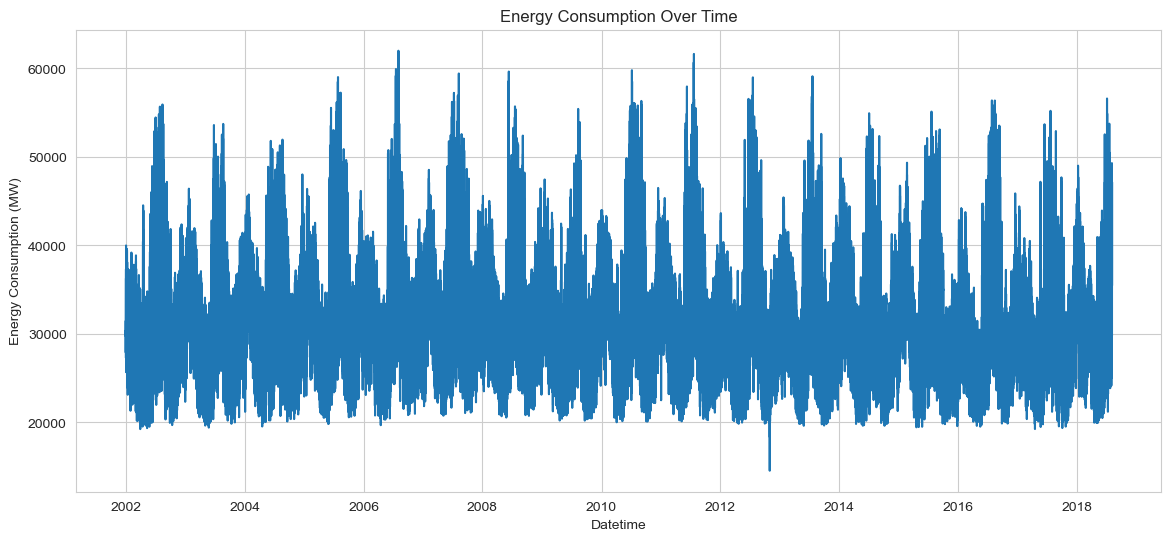

In [15]:
# Grafico panoramica storica
plt.plot(df.index, df["energy_consumption"])
plt.title("Energy Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.show()

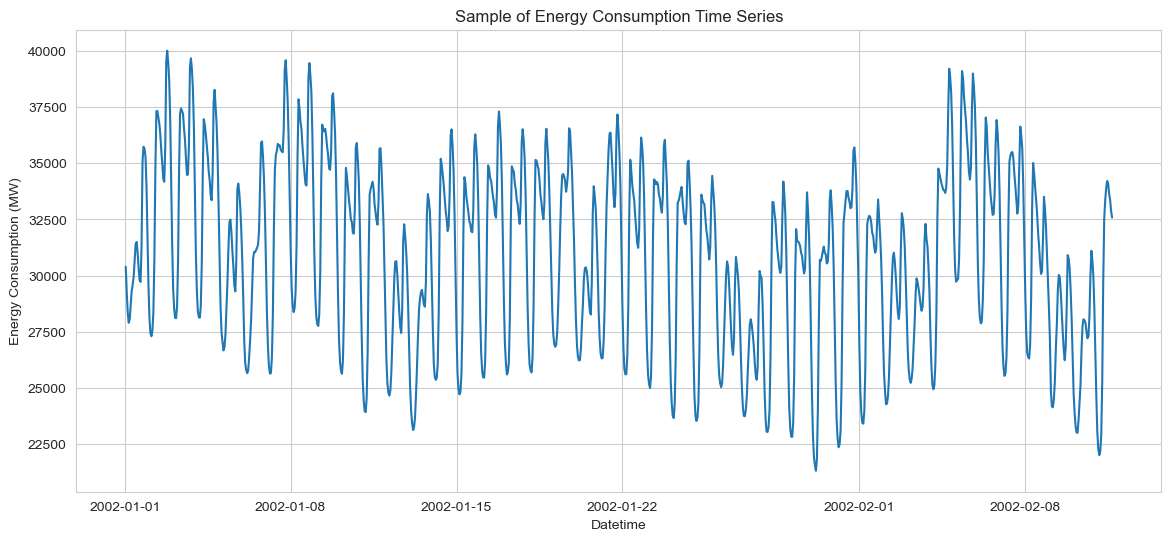

In [17]:
# Dataset molto pieno, quindi plot di una time serie più corta
sample = df.iloc[:1000]

plt.plot(sample.index, sample["energy_consumption"])
plt.title("Sample of Energy Consumption Time Series")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.show()

In [19]:
# Statistiche descrittive
df.describe()

,energy_consumption
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [21]:
# Creiamo feature temporali dalla data
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["quarter"] = df.index.quarter
df["month"] = df.index.month
df["year"] = df.index.year
df["dayofyear"] = df.index.dayofyear
df["dayofmonth"] = df.index.day
df["weekofyear"] = df.index.isocalendar().week.astype(int)

df.head()

,energy_consumption,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1


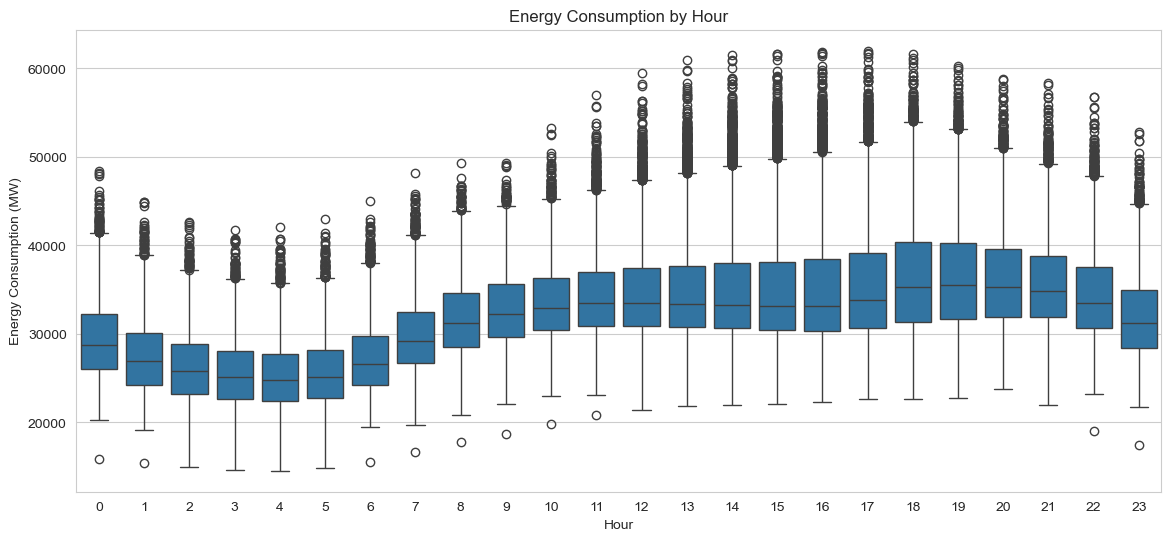

In [23]:
# Boxplot per ora
sns.boxplot(data=df, x="hour", y="energy_consumption")
plt.title("Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Energy Consumption (MW)")
plt.show()

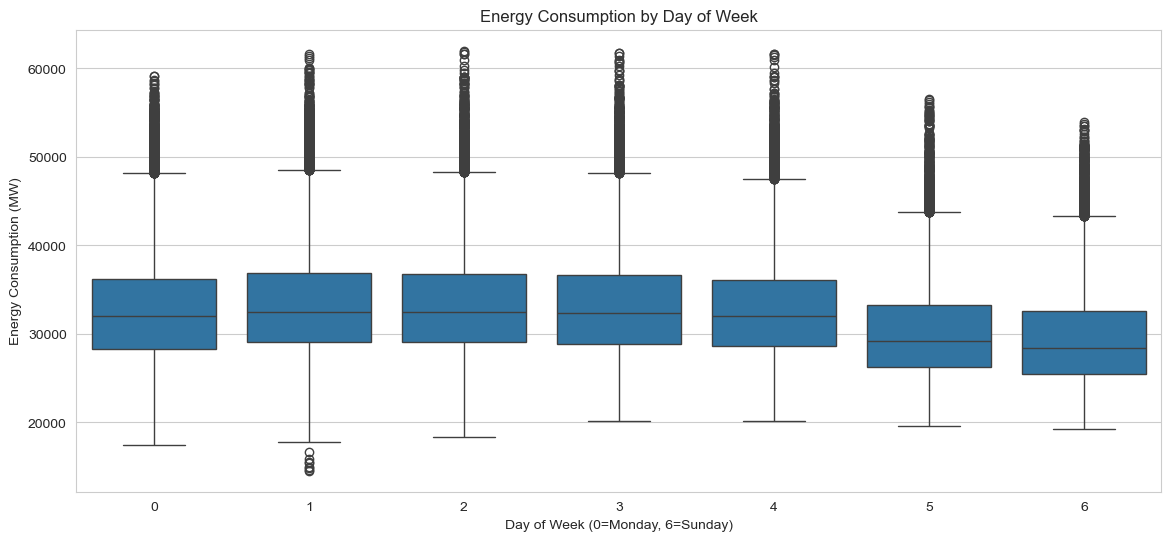

In [25]:
# Boxplot per giorno della settimana
sns.boxplot(data=df, x="dayofweek", y="energy_consumption")
plt.title("Energy Consumption by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Energy Consumption (MW)")
plt.show()

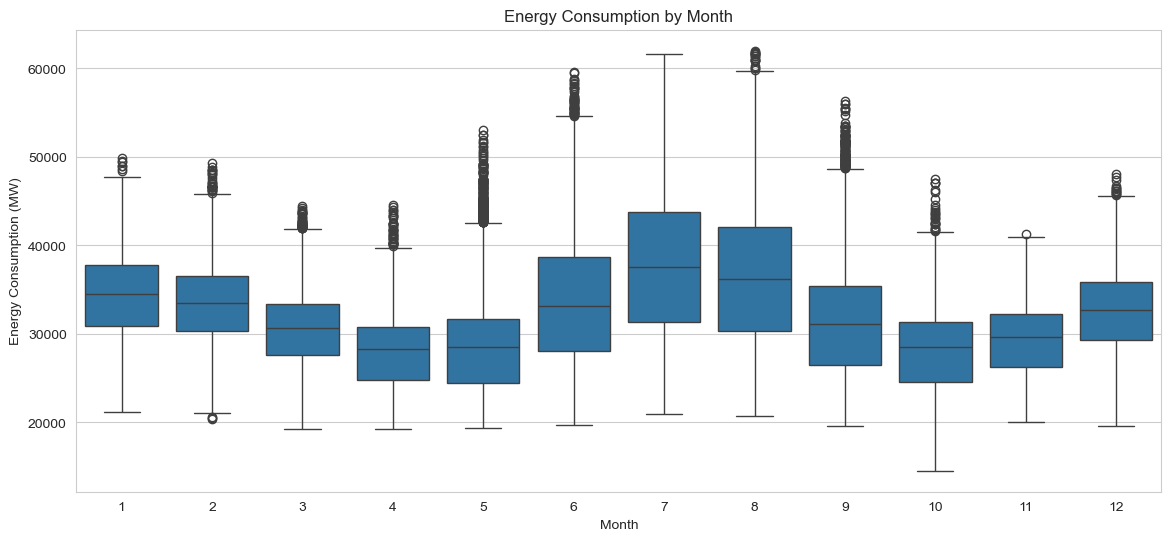

In [27]:
# Boxplot per mese
sns.boxplot(data=df, x="month", y="energy_consumption")
plt.title("Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (MW)")
plt.show()

In [ ]:
""Temporal Consumption Patterns

The boxplots highlight how electricity consumption varies across different temporal dimensions.

From the **hourly distribution**, we can observe that energy demand typically increases during daytime hours and peaks in the late afternoon or evening, when residential and commercial activity is higher.

The **day-of-week analysis** shows slightly lower consumption during weekends compared to weekdays, reflecting reduced industrial and business activity.

Finally, the **monthly distribution** indicates seasonal variation in electricity demand. Higher consumption periods are typically associated with extreme temperatures, where heating or cooling systems increase electricity usage.""

In [29]:
# Lag di 1 ora
df["lag_1h"] = df["energy_consumption"].shift(1)

# Lag di 24 ore
df["lag_24h"] = df["energy_consumption"].shift(24)

# Lag di 7 giorni = 24 * 7 ore
df["lag_7d"] = df["energy_consumption"].shift(24 * 7)

df.head(30)

,energy_consumption,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1h,lag_24h,lag_7d
Datetime,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,30393.0,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,29265.0,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,28357.0,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,27899.0,NaN,NaN
2002-01-01 06:00:00,28654.0,6,1,1,1,2002,1,1,1,28057.0,NaN,NaN
2002-01-01 07:00:00,29308.0,7,1,1,1,2002,1,1,1,28654.0,NaN,NaN
2002-01-01 08:00:00,29595.0,8,1,1,1,2002,1,1,1,29308.0,NaN,NaN
2002-01-01 09:00:00,29943.0,9,1,1,1,2002,1,1,1,29595.0,NaN,NaN


In [ ]:
"" Lag Features

Lag features are variables that represent **past values of the target variable**.  
In time series forecasting, past observations are often strong predictors of future values.

In this project we create three lag variables:

- **lag_1h** → energy consumption one hour earlier  
- **lag_24h** → energy consumption at the same hour of the previous day  
- **lag_7d** → energy consumption at the same hour one week earlier  

These features help the model capture **temporal dependencies**, meaning that current energy demand is strongly influenced by recent historical consumption patterns.""

In [31]:
# Media mobile ultime 24 ore
df["rolling_mean_24h"] = df["energy_consumption"].shift(1).rolling(window=24).mean()

# Deviazione standard ultime 24 ore
df["rolling_std_24h"] = df["energy_consumption"].shift(1).rolling(window=24).std()

# Media mobile ultimi 7 giorni
df["rolling_mean_7d"] = df["energy_consumption"].shift(1).rolling(window=24 * 7).mean()

df.head(30)

,energy_consumption,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1h,lag_24h,lag_7d,rolling_mean_24h,rolling_std_24h,rolling_mean_7d
Datetime,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,30393.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,29265.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,28357.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,27899.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 06:00:00,28654.0,6,1,1,1,2002,1,1,1,28057.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 07:00:00,29308.0,7,1,1,1,2002,1,1,1,28654.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 08:00:00,29595.0,8,1,1,1,2002,1,1,1,29308.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 09:00:00,29943.0,9,1,1,1,2002,1,1,1,29595.0,NaN,NaN,NaN,NaN,NaN


In [33]:

# Le lag e rolling creano valori mancanti all'inizio
df = df.dropna()

print("Shape dopo rimozione NaN:", df.shape)
df.head()

Shape dopo rimozione NaN: (145198, 15)


,energy_consumption,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1h,lag_24h,lag_7d,rolling_mean_24h,rolling_std_24h,rolling_mean_7d
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,8,2,31187.0,26862.0,30393.0,33452.583333,4559.767709,32519.511905
2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,8,2,29445.0,25976.0,29265.0,33560.208333,4425.965952,32513.869048
2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,8,2,28670.0,25641.0,28357.0,33672.458333,4256.159403,32510.327381
2002-01-08 04:00:00,28542.0,4,1,1,1,2002,8,8,2,28375.0,25666.0,27899.0,33786.375000,4064.104959,32510.434524
2002-01-08 05:00:00,29261.0,5,1,1,1,2002,8,8,2,28542.0,26328.0,28057.0,33906.208333,3851.076461,32514.261905


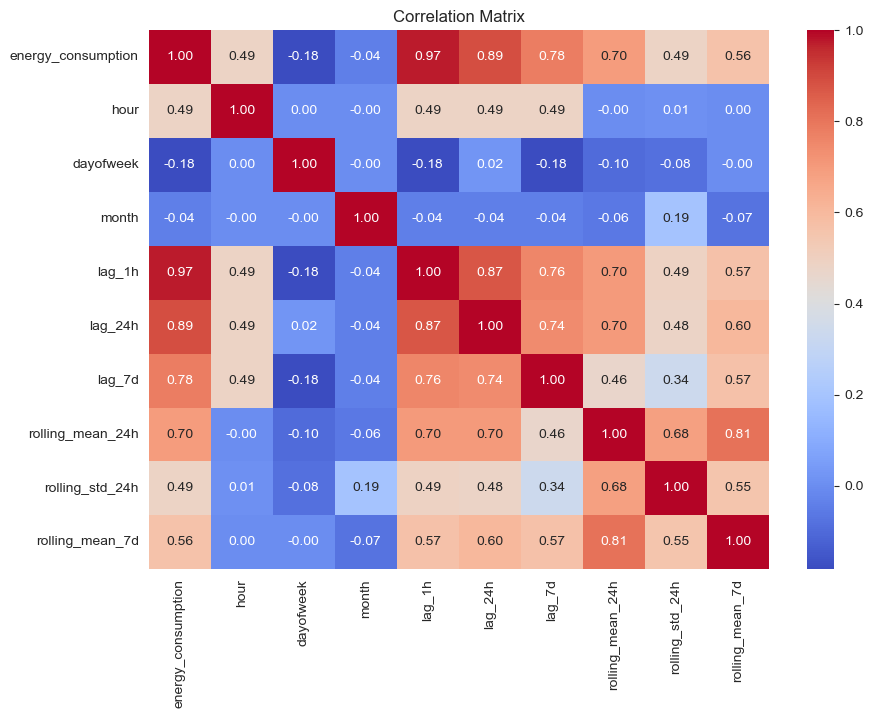

In [35]:
corr_cols = [
    "energy_consumption",
    "hour",
    "dayofweek",
    "month",
    "lag_1h",
    "lag_24h",
    "lag_7d",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_7d"
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
"" Correlation Analysis

The correlation matrix helps identify which variables are most related to the target variable.

As expected, the **lag features show the strongest correlation with current energy consumption**, especially the one-hour lag.  
This indicates that electricity demand tends to follow short-term patterns where recent consumption is highly predictive of the next value.

Rolling statistics and time-based variables also contribute useful information, capturing broader consumption trends and seasonal effects.""

In [37]:
features = [
    "hour",
    "dayofweek",
    "quarter",
    "month",
    "year",
    "dayofyear",
    "dayofmonth",
    "weekofyear",
    "lag_1h",
    "lag_24h",
    "lag_7d",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_7d"
]

target = "energy_consumption"

X = df[features]
y = df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (145198, 14)
Shape y: (145198,)


In [39]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nPeriodo train:")
print(X_train.index.min(), "->", X_train.index.max())

print("\nPeriodo test:")
print(X_test.index.min(), "->", X_test.index.max())

Train size: (116158, 14)
Test size: (29040, 14)

Periodo train:
2002-01-08 01:00:00 -> 2015-04-11 00:00:00

Periodo test:
2015-04-11 01:00:00 -> 2018-08-03 00:00:00


In [73]:
# Baseline semplice:
# prevediamo che il consumo attuale sia uguale al consumo di 1 ora prima
y_pred_naive = X_test["lag_1h"].values

# Valutazione baseline
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive = r2_score(y_test, y_pred_naive)
mape_naive = mean_absolute_percentage_error(y_test, y_pred_naive)

print("Naive Baseline Results")
print("----------------------")
print("MAE :", round(mae_naive, 2))
print("RMSE:", round(rmse_naive, 2))
print("R2  :", round(r2_naive, 4))
print("MAPE:", round(mape_naive, 4))

Naive Baseline Results
----------------------
MAE : 1070.05
RMSE: 1373.87
R2  : 0.9552
MAPE: 0.0348


In [ ]:
"" Baseline Forecast

Before evaluating machine learning models, a naive forecasting baseline is introduced.  
This baseline assumes that the energy consumption at the current hour is equal to the consumption observed one hour earlier.

Including a baseline is important because it provides a minimum reference point: a forecasting model should only be considered useful if it performs better than this simple rule.""

In [41]:
# Modello Linear regressor
lr_model = LinearRegression()

# Addestramento
lr_model.fit(X_train, y_train)

# Predizioni
y_pred_lr = lr_model.predict(X_test)

In [69]:
# Valutazione linear regressor
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R2  :", round(r2_lr, 4))
print("MAPE:", round(mape_lr, 4))

Linear Regression Results
-------------------------
MAE : 969.27
RMSE: 1239.6
R2  : 0.9635
MAPE: 0.0313


In [45]:
# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Addestramento
rf_model.fit(X_train, y_train)

# Predizioni
y_pred_rf = rf_model.predict(X_test)

In [71]:
# Valutazione Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R2  :", round(r2_rf, 4))
print("MAPE:", round(mape_rf, 4))

Random Forest Results
---------------------
MAE : 368.98
RMSE: 509.84
R2  : 0.9938
MAPE: 0.0117


In [75]:
# Confronto modelli
results = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_naive, mae_lr, mae_rf],
    "RMSE": [rmse_naive, rmse_lr, rmse_rf],
    "R2": [r2_naive, r2_lr, r2_rf],
    "MAPE": [mape_naive, mape_lr, mape_rf]
})

results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2,MAPE
2,Random Forest,368.981512,509.843214,0.993832,0.011681
1,Linear Regression,969.270323,1239.595677,0.963540,0.031274
0,Naive Baseline,1070.045868,1373.866246,0.955214,0.034808


In [51]:
# Real vs Predicted
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_RF": y_pred_rf,
    "Predicted_LR": y_pred_lr
}, index=y_test.index)

comparison_df.head()

,Actual,Predicted_RF,Predicted_LR
Datetime,,,
2015-04-11 01:00:00,23728.0,23726.431888,25246.488227
2015-04-11 02:00:00,22743.0,22627.924580,23728.813986
2015-04-11 03:00:00,22276.0,22022.232873,22838.894215
2015-04-11 04:00:00,22029.0,21948.982309,22441.781156
2015-04-11 05:00:00,22248.0,22145.766431,22345.140804


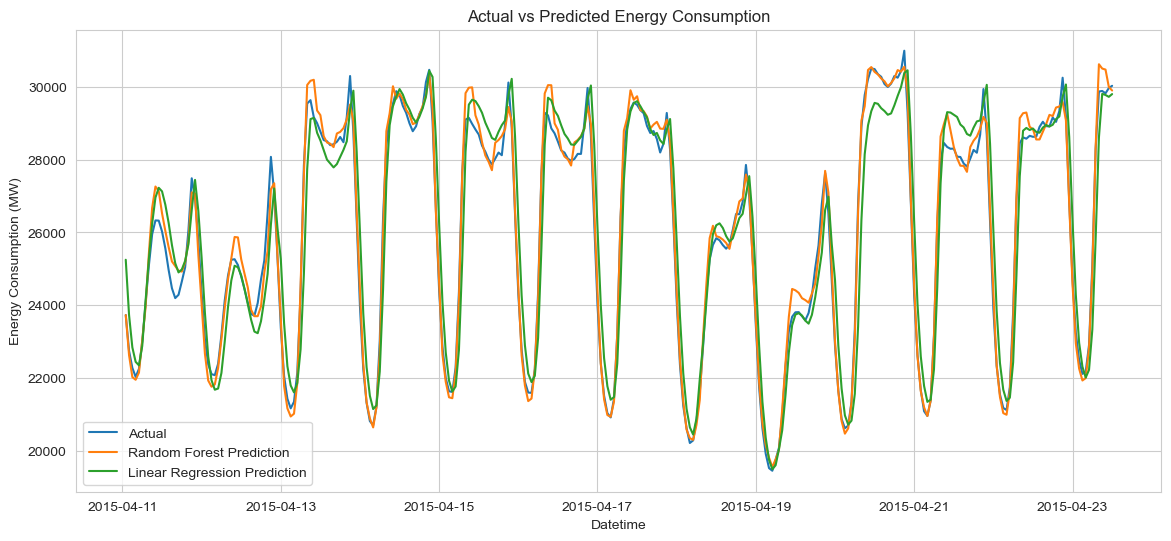

In [53]:
# plot di prime 300 previsioni del test 
plt.figure(figsize=(14, 6))

plt.plot(comparison_df.index[:300], comparison_df["Actual"][:300], label="Actual")
plt.plot(comparison_df.index[:300], comparison_df["Predicted_RF"][:300], label="Random Forest Prediction")
plt.plot(comparison_df.index[:300], comparison_df["Predicted_LR"][:300], label="Linear Regression Prediction")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.show()

In [59]:
# esempio di previsione
comparison_df.tail(10)

,Actual,Predicted_RF,Predicted_LR
Datetime,,,
2018-08-02 15:00:00,47154.0,47221.079931,46810.495124
2018-08-02 16:00:00,46989.0,47782.807452,47653.906263
2018-08-02 17:00:00,46816.0,47240.889398,47805.165423
2018-08-02 18:00:00,46760.0,46539.022140,47792.526552
2018-08-02 19:00:00,45641.0,45232.274628,47509.155577
2018-08-02 20:00:00,44057.0,44133.595404,46214.687445
2018-08-02 21:00:00,43256.0,43076.993434,44692.661070
2018-08-02 22:00:00,41552.0,42122.621950,43567.824707
2018-08-02 23:00:00,38500.0,38591.383913,41360.460902


In [ ]:
"" Robustness Check Without the Strongest Lag

The feature importance analysis showed that `lag_1h` is by far the most influential predictor.  
To make the analysis more robust, an additional experiment was performed by removing this feature.

This allows us to evaluate whether the model still performs well when the strongest short-term autoregressive signal is excluded.  
The comparison helps determine whether the forecasting performance relies only on the previous hour or also on broader temporal patterns captured by other features.""

In [55]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df

,feature,importance
8,lag_1h,0.953628
0,hour,0.040182
12,rolling_std_24h,0.002200
1,dayofweek,0.001410
11,rolling_mean_24h,0.001160
5,dayofyear,0.000474
9,lag_24h,0.000384
7,weekofyear,0.000148
13,rolling_mean_7d,0.000137
10,lag_7d,0.000118


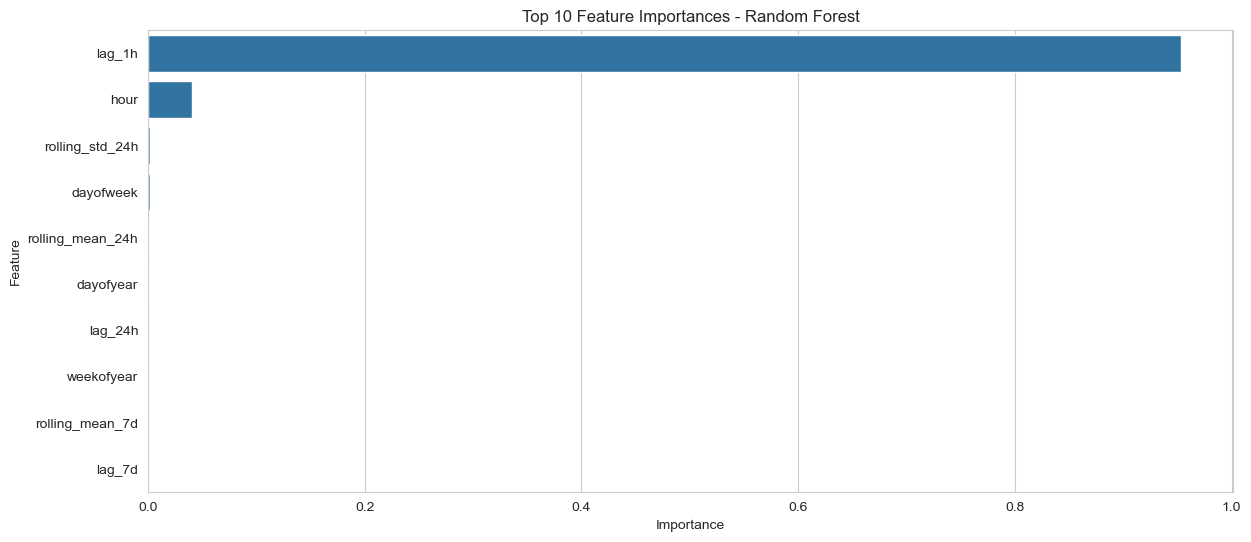

In [57]:
top_features = feature_importance_df.head(10)

sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [81]:
# Esperimento senza lag_1h
features_no_lag1 = [
    "hour",
    "dayofweek",
    "quarter",
    "month",
    "year",
    "dayofyear",
    "dayofmonth",
    "weekofyear",
    "lag_24h",
    "lag_7d",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_7d"
]

X_no_lag1 = df[features_no_lag1]

X_train_nl1 = X_no_lag1.iloc[:split_index]
X_test_nl1 = X_no_lag1.iloc[split_index:]

rf_no_lag1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_no_lag1.fit(X_train_nl1, y_train)
y_pred_rf_nl1 = rf_no_lag1.predict(X_test_nl1)

mae_rf_nl1 = mean_absolute_error(y_test, y_pred_rf_nl1)
rmse_rf_nl1 = np.sqrt(mean_squared_error(y_test, y_pred_rf_nl1))
r2_rf_nl1 = r2_score(y_test, y_pred_rf_nl1)
mape_rf_nl1 = mean_absolute_percentage_error(y_test, y_pred_rf_nl1)

print("Random Forest without lag_1h")
print("----------------------------")
print("MAE :", round(mae_rf_nl1, 2))
print("RMSE:", round(rmse_rf_nl1, 2))
print("R2  :", round(r2_rf_nl1, 4))
print("MAPE:", round(mape_rf_nl1, 4))

Random Forest without lag_1h
----------------------------
MAE : 1329.0
RMSE: 1801.95
R2  : 0.923
MAPE: 0.0426


In [83]:
extended_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "Random Forest (without lag_1h)"
    ],
    "MAE": [mae_naive, mae_lr, mae_rf, mae_rf_nl1],
    "RMSE": [rmse_naive, rmse_lr, rmse_rf, rmse_rf_nl1],
    "R2": [r2_naive, r2_lr, r2_rf, r2_rf_nl1],
    "MAPE": [mape_naive, mape_lr, mape_rf, mape_rf_nl1]
})

extended_results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2,MAPE
2,Random Forest,368.981512,509.843214,0.993832,0.011681
1,Linear Regression,969.270323,1239.595677,0.963540,0.031274
0,Naive Baseline,1070.045868,1373.866246,0.955214,0.034808
3,Random Forest (without lag_1h),1329.001235,1801.953034,0.922955,0.042572


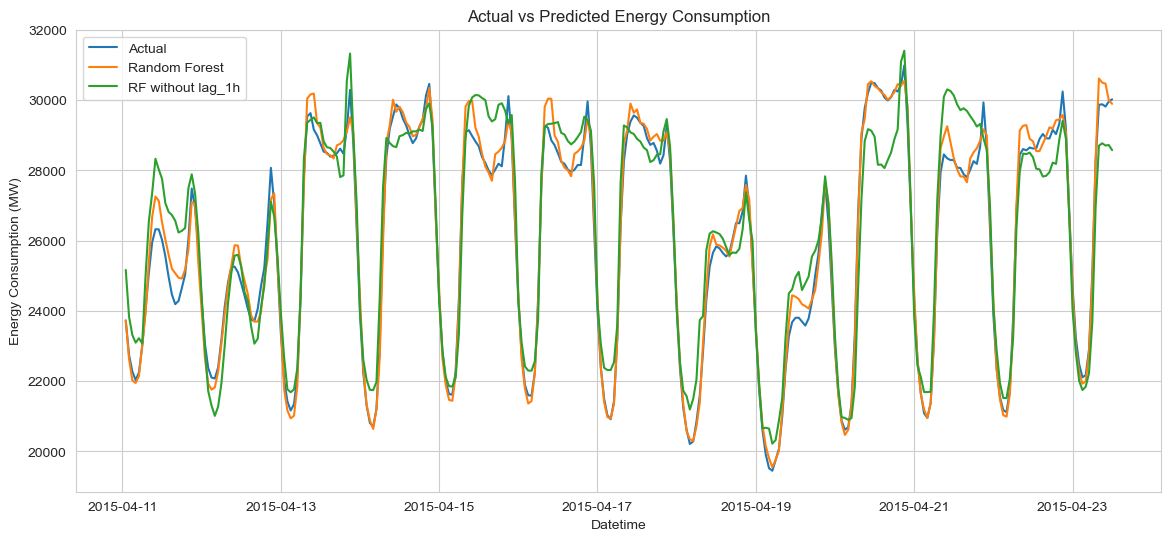

In [85]:
comparison_advanced = pd.DataFrame({
    "Actual": y_test.values,
    "Random Forest": y_pred_rf,
    "RF without lag_1h": y_pred_rf_nl1
}, index=y_test.index)

plt.figure(figsize=(14, 6))
plt.plot(comparison_advanced.index[:300], comparison_advanced["Actual"][:300], label="Actual")
plt.plot(comparison_advanced.index[:300], comparison_advanced["Random Forest"][:300], label="Random Forest")
plt.plot(comparison_advanced.index[:300], comparison_advanced["RF without lag_1h"][:300], label="RF without lag_1h")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.show()

In [61]:
# Creiamo la cartella models se non esiste
os.makedirs("models", exist_ok=True)

# Salviamo il modello
joblib.dump(rf_model, "models/energy_forecasting_random_forest.pkl")

print("Modello salvato correttamente.")

Modello salvato correttamente.


In [63]:
joblib.dump(features, "models/energy_forecasting_features.pkl")

print("Lista feature salvata correttamente.")

Lista feature salvata correttamente.
